# Classic NLP Baselines

This notebook walks through:

1. **Implement a trigram language model (LM)** with add-*k* smoothing and computing **perplexity** on a test set.  
2. **Train a Logistic Regression** text classification baseline and do basic error analysis.

# Language Modelling using N-gram



## Load the data and split

In [ ]:
import nltk
from nltk.corpus import brown

# NLTK data
nltk.download('brown') # Downloads the Brown Corpus files

# Dataset loading
sents = brown.sents(categories='news')

# TODO: Train validation split
train_sents = [...]
test_sents = [...]

print(f"Training Sentences: {len(train_sents)}")
print(f"Testing Sentences: {len(test_sents)}")

Training Sentences: 1
Testing Sentences: 1


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!


##Trigram Model Implementation
A trigram model approximates the probability of a word given its previous two words:

$$P( w_{i}| w_{i-2}, w_{i-1}) = \frac{C(w_{i-2}, w_{i-1}, w_{i})}{C(w_{i-2}, w_{i-1})}$$

Laplace (Add-1) Smoothing is implemented to handle the sparsity problem.

$$
P(w_i \mid w_{i-2}, w_{i-1}) =
\frac{C(w_{i-2}, w_{i-1}, w_i) + k}{C(w_{i-2}, w_{i-1}) + k \cdot |V|}
$$

Where $|V|$ is vocabulary size.

In [ ]:
from collections import defaultdict
import numpy as np
import math

class TrigramLanguageModel:
    def __init__(self):
        self.bigram_counts = defaultdict(int)
        self.trigram_counts = defaultdict(int)
        self.vocab = set()

    def preprocess(self, sentence):
        # Add start/end tokens for trigram context
        return ["<s>"] + [w.lower() for w in sentence] + ["</s>"]

    def train(self, sentences):
        print("Training Trigram Model...")
        for sentence in sentences:
            tokens = self.preprocess(sentence)
            self.vocab.update(tokens)

            # Count Bigrams and Trigrams
            for i in range(2, len(tokens)):
                w_prev2 = tokens[i-2]
                w_prev1 = tokens[i-1]
                w_curr = tokens[i]

                self.bigram_counts[(w_prev2, w_prev1)] += 1
                self.trigram_counts[(w_prev2, w_prev1, w_curr)] += 1

        self.vocab_size = len(self.vocab)
        print(f"Training complete. Vocab size: {self.vocab_size}")

    def get_prob(self, w_prev2, w_prev1, w_curr, smoothing_k=1.0):
        """
        Calculates P(w_curr | w_prev2, w_prev1) with Add-k smoothing.
        """
        # TODO: Count the trigrams and bigrams

        # TODO: Apply smoothing formula

        return ...

In [ ]:
# Initialize and Train
lm = TrigramLanguageModel()
lm.train(train_sents)

Training Trigram Model...
Training complete. Vocab size: 11425


### Exercise

Extend the class above and add linear interpolation:

$$
P(w_{i}|w_{i-2}, w_{i-1})=\lambda_{1}P(w_{i}|w_{i-2}, w_{i-1})+\lambda_{2}P(w_{i}|w_{i-1})+\lambda_{3}P(w_{i})
$$

## Perplexity

Perplexity is the inverse probability of the test set, normalized by the number of words. (Lower perplexity indicates a better model)
$$
\mathrm{PP}(w_{1:N})=\left(\prod_{i=1}^{N} P\!\left(w_i \mid w_{i-2},\,w_{i-1}\right)\right)^{-1/N}
$$


To prevent numerical underflow, we sum log probabilities:
$$
\mathrm{PP}(W)=\exp\!\left(-\frac{1}{N}\sum_{i=1}^{N}\ln P\!\left(w_i \mid h_i\right)\right)
$$

In [ ]:
def compute_perplexity(model, sentences, k = 1.0):
    log_prob_sum = 0
    N = 0

    for sentence in sentences:
        tokens = model.preprocess(sentence)

        for i in range(2, len(tokens)):
            w_prev2 = tokens[i-2]
            w_prev1 = tokens[i-1]
            w_curr = tokens[i]

            prob = model.get_prob(w_prev2, w_prev1, w_curr, k)

            # TODO: Sum log probabilities (using natural log)

    # TODO: Calculate Perplexity
    perplexity = ...
    return perplexity

In [ ]:
# Evaluate
train_pp = compute_perplexity(lm, train_sents)
test_pp = compute_perplexity(lm, test_sents)

print(f"Train Perplexity: {train_pp:.2f}")
print(f"Test Perplexity:  {test_pp:.2f}")

Train Perplexity: 4910.19
Test Perplexity:  9732.10


Why is the Test Perplexity significantly higher than the Train Perplexity? How would increasing the smoothing parameter k affect this?

k          | Train PP     | Test PP     
----------------------------------------
0.001      | 14.73        | 6767.38     
0.005      | 55.17        | 6563.85     
0.01       | 102.63       | 6712.78     
0.02       | 194.18       | 6975.64     
0.05       | 455.36       | 7474.34     
0.1        | 859.41       | 7945.70     
0.2        | 1574.71      | 8473.81     
0.5        | 3198.21      | 9204.98     
1.0        | 4910.19      | 9732.10     
2.0        | 6747.39      | 10194.37    
5.0        | 8788.12      | 10668.80    
10.0       | 9838.16      | 10922.82    


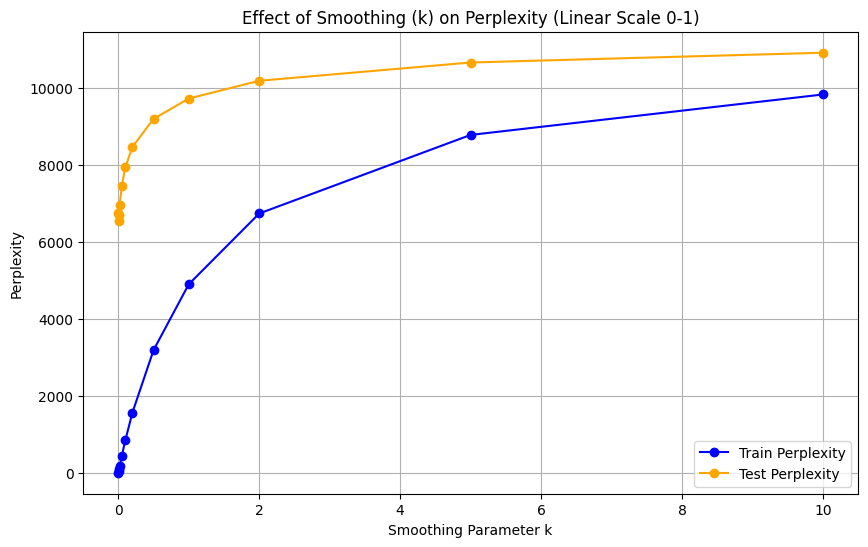

In [ ]:
import matplotlib.pyplot as plt

k_values_linear = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

train_perplexities = []
test_perplexities = []

print(f"{'k':<10} | {'Train PP':<12} | {'Test PP':<12}")
print("-" * 40)

for k in k_values_linear:
  # TODO: Compute perplexities
    train_pp = ...
    test_pp = ...

    train_perplexities.append(train_pp)
    test_perplexities.append(test_pp)

    print(f"{k:<10} | {train_pp:<12.2f} | {test_pp:<12.2f}")

plt.figure(figsize=(10, 6))

plt.plot(k_values_linear, train_perplexities, marker='o', label='Train Perplexity', color='blue')
plt.plot(k_values_linear, test_perplexities, marker='o', label='Test Perplexity', color='orange')

plt.xlabel('Smoothing Parameter k')
plt.ylabel('Perplexity')
plt.title('Effect of Smoothing (k) on Perplexity (Linear Scale 0-1)')
plt.legend()
plt.grid(True)
plt.show()

# Text Classification using Logistic Regression

## Load the data

In [ ]:
from sklearn.datasets import fetch_20newsgroups

categories = ['sci.space', 'rec.autos', 'comp.graphics', 'talk.politics.mideast']

newsgroups_train =  fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)

print(f"Train samples: {len(newsgroups_train.data)}")
print(f"Test samples: {len(newsgroups_test.data)}")

Train samples: 2335
Test samples: 1555


In [ ]:
import pandas as pd

newsgroup_full = fetch_20newsgroups(subset="all", categories=None)
df = pd.DataFrame({
    "text" : newsgroup_full.data,
    "target_id" : newsgroup_full.target,
    "category" : [newsgroup_full.target_names[i] for i in newsgroup_full.target]
})
df.head()

,text,target_id,category
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,10,rec.sport.hockey
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...,3,comp.sys.ibm.pc.hardware
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...,17,talk.politics.mideast
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...,3,comp.sys.ibm.pc.hardware
4,From: Alexander Samuel McDiarmid <am2o+@andrew...,4,comp.sys.mac.hardware


## Vectorize texts into sparse TF-IDF features and split the data

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train = tfidf.fit_transform(newsgroups_train.data)
X_test = tfidf.transform(newsgroups_test.data)

# TODO: Define target train and test sets

## Train logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# TODO: Train logistic regression

LogisticRegression(max_iter=1000, random_state=42)

## Evaluate on dev set

                       precision    recall  f1-score   support

        comp.graphics       0.92      0.95      0.93       389
            rec.autos       0.94      0.97      0.95       396
            sci.space       0.96      0.93      0.94       394
talk.politics.mideast       0.99      0.95      0.97       376

             accuracy                           0.95      1555
            macro avg       0.95      0.95      0.95      1555
         weighted avg       0.95      0.95      0.95      1555



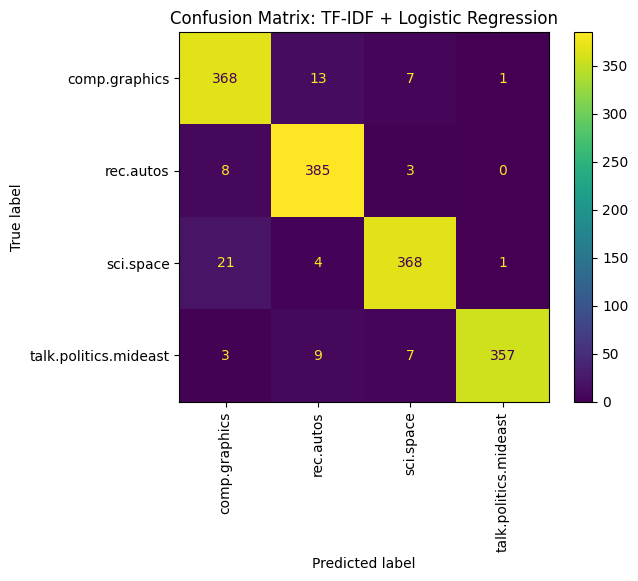

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# TODO: Make predictions
y_pred = ...

print(classification_report(y_test, y_pred, target_names=newsgroups_train.target_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=newsgroups_train.target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")
plt.show()

## Error analysis

In [ ]:
df_predictions = pd.DataFrame({
    'text': newsgroups_test.data,
    'true_label': [newsgroups_train.target_names[i] for i in y_test],
    'pred_label': [newsgroups_train.target_names[i] for i in y_pred]
})

errors = df_predictions[df_predictions['true_label'] != df_predictions['pred_label']]

print(f"Total Errors: {len(errors)}")
print("Displaying first 20 misclassifications:")

#pd.set_option('display.max_colwidth', 150)
display(errors.head(20))

Total Errors: 77
Displaying first 20 misclassifications:


,text,true_label,pred_label
16,From: born@scepter.ibm.com (Christopher J. Bor...,rec.autos,comp.graphics
47,From: binglis@health.ufl.edu (binglis)\nSubjec...,sci.space,comp.graphics
53,From: rousself@cicb.fr ( Frank ROUSSEL )\nSubj...,sci.space,comp.graphics
85,From: curdm@uxa.ecn.bgu.edu (Richard Mancuso)\...,comp.graphics,rec.autos
103,From: clements@vax.oxford.ac.uk\nSubject: Re: ...,sci.space,comp.graphics
111,From: khalid@bunce.hw.stratus.com (Khalid Chis...,talk.politics.mideast,rec.autos
153,From: f54oguocha@edison.usask.ca\nSubject: RE:...,talk.politics.mideast,rec.autos
168,From: cza@troy.cc.bellcore.com (C. Akgun)\nSub...,talk.politics.mideast,rec.autos
195,From: roy@mchip00.med.nyu.edu (Roy Smith)\nSub...,comp.graphics,rec.autos
208,From: wingo%cspara.decnet@Fedex.Msfc.Nasa.Gov\...,sci.space,comp.graphics
